# AI Agents & Agentic AI in Python — with **LangGraph**

**Stack:** Groq (`llama-3.3-70b-versatile`) · Tavily (web search) · LangGraph (orchestration)

This notebook tells one story in four beats:

| Beat | Demo | What it proves |
|------|------|----------------|
| **0. Cold open** | A bare LLM answering a question it can't know | *Why tools exist* |
| **Part 1 · Agent** | One agent, one tool (search) | A model can **use** a tool |
| **Part 2 · Rung 1** | One agent, many tools | A model can **choose** a tool |
| **Part 2 · Pattern A** | Planner → Executor | An agent can **delegate** |
| **Part 2 · Pattern B** | Orchestrator → parallel Workers (Trip Architect) | Agents can work **in parallel** |
| **Part 2 · Pattern C** | Generator ⇄ Evaluator (self-correcting coder) | An agent can **correct itself** — the thing a plain chain *cannot* do |

> Patterns A / B / C are the three reusable shapes from the *Common multi-agent patterns* slide:
> **Planner–Executor**, **Orchestrator–Workers**, and **Evaluator–Optimizer**.

---
## 0 · Setup

### 0.1 Install — what each package is for

| Package | Why it's here |
|---|---|
| `langgraph` | The orchestration engine. Installing it also pulls in **`langgraph-prebuilt`** (gives us `create_react_agent`) and **`langgraph-checkpoint`** (memory / persistence). |
| `langchain` | The shared vocabulary — `@tool`, the message classes, model helpers. LangGraph reuses LangChain's tool & message spec rather than inventing its own. |
| `langchain-groq` | The `ChatGroq` wrapper, so Llama-3.3-70B on Groq speaks the standard LangChain interface (`.invoke`, `.bind_tools`). |
| `langchain-tavily` | The **current** Tavily integration, exposing `TavilySearch` as a ready-made tool. *(The old `TavilySearchResults` from `langchain_community` is deprecated.)* |
| `python-dotenv` | Loads API keys from a `.env` file instead of hard-coding them. |
| `grandalf` | *(optional)* lets us draw the graph as ASCII inside the notebook. |

Run `pip install langgraph langchain langchain-groq langchain-tavily python-dotenv grandalf` in your virtual environment

### 0.2 API keys

Get free keys from **console.groq.com** and **app.tavily.com**, then paste them when prompted
(or put them in a `.env` file as `GROQ_API_KEY=...` and `TAVILY_API_KEY=...`).

In [1]:
import os, getpass
from dotenv import load_dotenv

load_dotenv()  # picks up a .env file if you have one

for key in ("GROQ_API_KEY", "TAVILY_API_KEY"):
    if not os.environ.get(key):
        os.environ[key] = getpass.getpass(f"Enter your {key}: ")

print("Keys loaded:", all(os.environ.get(k) for k in ("GROQ_API_KEY", "TAVILY_API_KEY")))

Keys loaded: True


### 0.3 The model

`temperature=0` keeps the agent's reasoning steady and reproducible.

In [2]:
from langchain_groq import ChatGroq

llm = ChatGroq(model="llama-3.3-70b-versatile", temperature=0)

# quick smoke test
print(llm.invoke("Reply with exactly: ready").content)

ready


### 0.4 Two small helpers

`run_agent` streams a run and pretty-prints every step, so we can *see* the loop.
`show_graph` draws the graph structure (offline-safe).

In [3]:
def run_agent(app, user_text):
    '''Stream a graph/agent run and print each node's latest message.'''
    for step in app.stream({"messages": [("user", user_text)]}, stream_mode="updates"):
        for node, update in step.items():
            print(f"\n=== node: {node} ===")
            msgs = update.get("messages") if isinstance(update, dict) else None
            if msgs:
                msgs[-1].pretty_print()
            else:
                print(update)

def show_graph(app):
    '''Render the graph. Tries a PNG, falls back to ASCII, then to Mermaid text.'''
    g = app.get_graph()
    try:
        from IPython.display import Image, display
        display(Image(g.draw_mermaid_png()))
    except Exception:
        try:
            print(g.draw_ascii())
        except Exception:
            print(g.draw_mermaid())

---
## 1 · What is LangGraph?

**LangGraph** is a framework for building AI agents as **graphs**. You define:

- **State** — the shared data passed around (a typed dictionary).
- **Nodes** — Python functions or LLM calls that read the state and return updates to it.
- **Edges** — the connections that decide what runs next.

Unlike a plain *chain* (which runs start-to-finish in one direction), a LangGraph graph can:

- **branch** — *conditional edges*: "if the model asked for a tool, go to the tool node;"
- **loop** — run a node again until some condition is met;
- **run nodes in parallel** — fan out to several nodes at once, then fan back in.

That branching and looping is exactly what separates a real **agent** from a fixed pipeline.

**Key capabilities:** cycles (self-correction), conditional routing (send work to the right place),
persistence / memory (checkpoint state to pause, resume, or remember), and human-in-the-loop
(pause for approval mid-run). Used in production by teams at Klarna, Replit, and Uber.

> **The agent loop, in one line:** `think → act (call a tool) → observe (read result) → repeat → answer.`

---
## 2 · Cold open — why tools exist

Let's ask the model something it **cannot** know from its training data. Watch it answer
confidently anyway. This is the problem every tool we add will fix.

In [4]:
question = "What is today's top technology news headline? Answer in one sentence."
print(llm.invoke(question).content)
# ⚠️ Whatever it says is a guess — the model has no live information and no way to check.

As my knowledge cutoff is December 2023, I don't have real-time information, but I can suggest checking reputable tech news websites such as TechCrunch, The Verge, or CNET for the latest technology news headlines.


---
# Part 1 · AI Agent — a single tool

We give the model exactly **one** tool: Tavily web search. Now it can *decide* to look things
up. Same model, one tool, completely different behaviour.

`create_agent` builds the classic agent loop for us (LLM ⇄ tools) in one line.


> *Note:* `create_agent` (from `langchain.agents`) is the current API for spinning up an agent. It replaces the now-deprecated `create_react_agent` from `langgraph.prebuilt` — same ReAct loop under the hood, plus a middleware system. 


In [5]:
from langchain_tavily import TavilySearch
from langchain.agents import create_agent

search_tool = TavilySearch(max_results=3)

search_agent = create_agent(
    llm,
    tools=[search_tool],
    system_prompt="You are a helpful research assistant. Use web search for anything "
           "time-sensitive or factual that you are not certain about.",
)

In [6]:
# Same question as the cold open — but now watch the loop: think -> search -> read -> answer.
run_agent(search_agent, "What is today's top technology news headline? Answer in one sentence.")


=== node: model ===
================================== Ai Message ==================================
Tool Calls:
  tavily_search (j57vbns7g)
 Call ID: j57vbns7g
  Args:
    query: today's top technology news
    search_depth: fast
    time_range: day

=== node: tools ===
================================= Tool Message =================================
Name: tavily_search

{"query": "today's top technology news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://techflu.co.uk/todays-top-technology-news-updates-and-trends", "title": "Today's Top Technology News Updates and Trends", "content": "funding scene shows a clear focus on AI and green tech. Today’s top tech news shows a world of fast-changing digital connections. These make your phone more personal and easy to use, thanks to AI. [...] use the headset’s advanced features. Recent EV news shows people really want these new electric cars. 6G research is exploring new frequency bands and AI networ

The graph LangGraph built for us — note the loop back from `tools` to the agent:

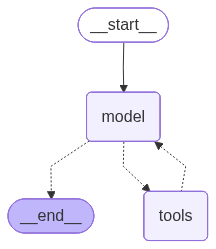

In [7]:
show_graph(search_agent)

---
# Part 2 · Agentic AI — many tools & sub-agents

A few reusable shapes cover most multi-agent designs:

- **Planner–Executor** — one agent plans the steps, a worker carries them out.
- **Orchestrator–Workers** — an orchestrator dispatches to several workers (often *in parallel*), then merges.
- **Evaluator–Optimizer** — a generator makes something, an evaluator grades it, and it loops: make → grade → improve.

We'll build one of each. But first, a bridge from Part 1.

## 2.1 · Bridge — one agent, *many* tools (tool **selection**)

Give a single agent two tools — search **and** a calculator — and a question that needs both.
Watch it pick the right tool for each sub-task and chain them.

In [8]:
from langchain_core.tools import tool

@tool
def calculator(expression: str) -> str:
    '''Evaluate an arithmetic expression like '128000000 / 11000000'.
    Supports + - * / ** % and parentheses. Use this for any exact arithmetic.'''
    import ast, operator as op
    ops = {ast.Add: op.add, ast.Sub: op.sub, ast.Mult: op.mul, ast.Div: op.truediv,
           ast.Pow: op.pow, ast.Mod: op.mod, ast.USub: op.neg, ast.UAdd: op.pos}
    def ev(node):
        if isinstance(node, ast.Constant):
            return node.value
        if isinstance(node, ast.BinOp):
            return ops[type(node.op)](ev(node.left), ev(node.right))
        if isinstance(node, ast.UnaryOp):
            return ops[type(node.op)](ev(node.operand))
        raise ValueError("unsupported expression")
    return str(ev(ast.parse(expression, mode="eval").body))

multi_tool_agent = create_agent(
    llm,
    tools=[search_tool, calculator],
    system_prompt="You are a precise assistant. Use web search to look up facts, and the "
           "calculator tool for any arithmetic. Never do arithmetic in your head.",
)

In [9]:
run_agent(
    multi_tool_agent,
    "What is the population of Japan divided by the population of Chennai? "
    "Search for each figure, then use the calculator."
)


=== node: model ===
================================== Ai Message ==================================
Tool Calls:
  tavily_search (jywypvhrx)
 Call ID: jywypvhrx
  Args:
    query: population of Japan
    search_depth: basic
    topic: general
  tavily_search (h9by955g0)
 Call ID: h9by955g0
  Args:
    query: population of Chennai
    search_depth: basic
    topic: general
  calculator (7mbjjssyp)
 Call ID: 7mbjjssyp
  Args:
    expression: 128000000 / 11000000

=== node: tools ===
================================= Tool Message =================================
Name: calculator

11.636363636363637

=== node: tools ===
================================= Tool Message =================================
Name: tavily_search

{"query": "population of Japan", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://en.wikipedia.org/wiki/Demographics_of_Japan", "title": "Demographics of Japan - Wikipedia", "content": "| Population | ![Image 5: Decrease](https://upl

## 2.2 · Pattern A — **Planner → Executor**

> *plans the steps, then a worker carries them out*

A **planner** node breaks the task into concrete research steps. An **executor** node (a search
agent) then carries the plan out and returns a consolidated answer. Two nodes, wired in sequence.

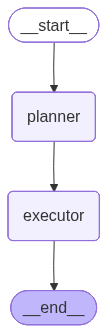

In [10]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END

class PlanState(TypedDict):
    task: str
    plan: str
    answer: str

def planner_node(state: PlanState):
    prompt = ("Break the user's task into a short numbered list of 2–4 concrete "
              f"research steps. Be specific.\n\nTask: {state['task']}")
    plan = llm.invoke(prompt).content
    print("PLAN:\n" + plan + "\n")
    return {"plan": plan}

executor_agent = create_agent(
    llm, tools=[search_tool],
    system_prompt="You execute a research plan using web search, then give one consolidated final answer.",
)

def executor_node(state: PlanState):
    msg = f"Task: {state['task']}\n\nFollow this plan:\n{state['plan']}\n\nResearch it, then answer."
    result = executor_agent.invoke({"messages": [("user", msg)]})
    return {"answer": result["messages"][-1].content}

pb = StateGraph(PlanState)
pb.add_node("planner", planner_node)
pb.add_node("executor", executor_node)
pb.add_edge(START, "planner")
pb.add_edge("planner", "executor")
pb.add_edge("executor", END)
planner_executor = pb.compile()

show_graph(planner_executor)

In [11]:
out = planner_executor.invoke(
    {"task": "Compare the latest flagship phones from Apple and Samsung on price and battery.",
     "plan": "", "answer": ""}
)
print(out["answer"])

PLAN:
Here are the concrete research steps to compare the latest flagship phones from Apple and Samsung on price and battery:

1. **Identify the latest flagship models**: Research and note down the latest flagship phone models from Apple (e.g. iPhone 14 Pro) and Samsung (e.g. Galaxy S23 Ultra) to ensure comparison of the most current devices.
2. **Gather price information**: Look up the official prices of the identified Apple and Samsung flagship models from reputable sources such as the companies' official websites, online marketplaces (e.g. Amazon), or technology news websites.
3. **Collect battery specification data**: Research and record the battery capacity (in mAh), battery life claims (e.g. talk time, internet use), and charging capabilities (e.g. fast charging, wireless charging) for each of the identified flagship models from Apple and Samsung.
4. **Compare and analyze the data**: Create a side-by-side comparison of the prices and battery specifications of the Apple and Samsun

## 2.3 · Pattern B — **Orchestrator → Workers (in parallel)** · The Trip Architect

> This is the **Orchestrator–Workers** shape from the slide, in its *parallel* form.

The orchestrator **fans out** to three independent workers — Flights, Hotels, Activities —
that run **at the same time**. A coordinator then **fans in** and merges their findings.

**The key idea — supersteps & reducers:** when several nodes write to the same state key at
once, LangGraph needs to know how to combine them. We mark `findings` with a *reducer*
(`operator.add`) so parallel writes are *appended* instead of overwriting each other.

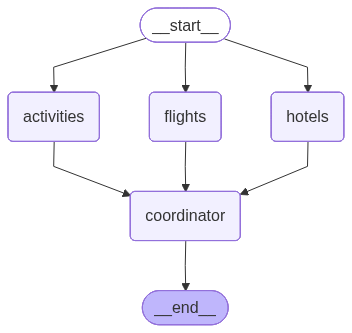

In [12]:
import operator
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END

# Define the state for the trip planning graph
class TripState(TypedDict):
    destination: str
    dates: str
    findings: Annotated[list, operator.add]   # reducer => parallel writes are appended
    itinerary: str

worker = create_agent(llm, tools=[search_tool])  # one reusable search worker

# Function to create worker nodes
def make_worker_node(label, ask):
    def node(state: TripState):
        q = ask.format(destination=state["destination"], dates=state["dates"])
        r = worker.invoke({"messages": [("user", q)]})
        return {"findings": [f"### {label}\n{r['messages'][-1].content}"]}
    return node

flights_node = make_worker_node(
    "Flights",
    "Find realistic flight options and rough fares to {destination} for {dates}. 3–4 bullets.")
hotels_node = make_worker_node(
    "Hotels",
    "Suggest 3 well-reviewed places to stay in {destination} for {dates}, with price bands.")
activities_node = make_worker_node(
    "Activities",
    "List 4–5 must-do activities in {destination} suitable for {dates}.")

def coordinator_node(state: TripState):
    research = "\n\n".join(state["findings"])
    prompt = (f"You are a trip coordinator. Using ONLY the research below, write a tidy "
              f"itinerary for {state['destination']} ({state['dates']}).\n\n{research}")
    return {"itinerary": llm.invoke(prompt).content}

tb = StateGraph(TripState)
tb.add_node("flights", flights_node)
tb.add_node("hotels", hotels_node)
tb.add_node("activities", activities_node)
tb.add_node("coordinator", coordinator_node)

# FAN-OUT: all three workers start in the same superstep
tb.add_edge(START, "flights")
tb.add_edge(START, "hotels")
tb.add_edge(START, "activities")

# FAN-IN: coordinator waits for ALL three to finish
tb.add_edge(["flights", "hotels", "activities"], "coordinator")
tb.add_edge("coordinator", END)

trip = tb.compile()
show_graph(trip)   # note the diamond: one split into three, then back into one

In [13]:
result = trip.invoke(
    {"destination": "Tokyo", "dates": "5 days in October",
     "findings": [], "itinerary": ""}
)
print(result["itinerary"])

**Tokyo 5-Day Itinerary (October)**

**Day 1: Arrival and Relaxation**

* Arrive in Tokyo and check-in to your hotel (choose from OMO3 Asakusa By Hoshino Resorts, MUJI Hotel, or Hotel Chinzanso)
* Visit the Hamarikyu Gardens for a serene afternoon stroll and enjoy the fall foliage
* Spend the evening exploring the local area and getting a feel for the city

**Day 2: Culture and History**

* Start the day with a visit to the Tokyo National Museum to learn about Japanese art and history
* In the afternoon, head to the Tokyo Tower for panoramic views of the city
* Enjoy a traditional Japanese dinner and relax at your hotel

**Day 3: Film and Entertainment**

* Spend the day experiencing the Tokyo International Film Festival, one of the largest film festivals in Asia
* Catch a few film screenings and enjoy the festival atmosphere
* In the evening, explore the local nightlife and try some traditional Japanese cuisine

**Day 4: Food and Markets**

* Visit the Tsukiji Outer Market for a sushi

**What just happened:** Flights, Hotels and Activities ran *concurrently* in one LangGraph
*superstep*, each appending to `findings` via the reducer. The coordinator only fired once all
three were done. Sequentially this would take ~3× as long.

## 2.4 · Pattern C — **Generator ⇄ Evaluator** · The Self-Correcting Coder

> *loops: make → grade → improve* — the **Evaluator–Optimizer** shape.

This is the demo a plain chain **cannot** do. A **generator** writes code; an **evaluator** runs
real tests; a **conditional edge** loops back to the generator with the failure feedback until the
tests pass (or we hit a safety cap). The agent fixes its own mistakes.

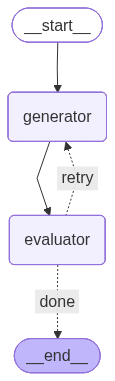

In [14]:
import re
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END

class CodeState(TypedDict):
    task: str
    code: str
    feedback: str
    iterations: int
    passed: bool

# Hidden test suite the evaluator runs against the generated function
TESTS = [("is_prime(2)", True), ("is_prime(1)", False), ("is_prime(0)", False),
         ("is_prime(-7)", False), ("is_prime(97)", True), ("is_prime(100)", False),
         ("is_prime(7919)", True)]

def extract_code(text):
    m = re.search(r"```(?:python)?\n(.*?)```", text, re.DOTALL)
    return (m.group(1) if m else text).strip()

def generator_node(state: CodeState):
    if state.get("feedback"):
        prompt = (f"Your previous solution to this task failed:\n{state['task']}\n\n"
                  f"Failures:\n{state['feedback']}\n\nFix it. Return ONLY a python code block.")
    else:
        prompt = f"Write a Python function for this task:\n{state['task']}\n\nReturn ONLY a python code block."
    code_text = extract_code(llm.invoke(prompt).content)
    print(f"\n--- attempt {state.get('iterations', 0) + 1} ---\n{code_text}")
    return {"code": code_text, "iterations": state.get("iterations", 0) + 1}

def evaluator_node(state: CodeState):
    ns = {}
    try:
        exec(state["code"], ns)
    except Exception as e:
        return {"passed": False, "feedback": f"Code failed to load: {e!r}"}
    if "is_prime" not in ns:
        return {"passed": False, "feedback": "No function named is_prime was defined."}
    failures = []
    for expr, expected in TESTS:
        try:
            got = eval(expr, ns)
            if got != expected:
                failures.append(f"{expr} -> {got}, expected {expected}")
        except Exception as e:
            failures.append(f"{expr} raised {e!r}")
    if failures:
        print("failed:", "; ".join(failures))
        return {"passed": False, "feedback": "\n".join(failures)}
    print("all tests passed")
    return {"passed": True, "feedback": ""}

def route(state: CodeState):
    if state["passed"] or state["iterations"] >= 3:
        return "done"
    return "retry"

cb = StateGraph(CodeState)
cb.add_node("generator", generator_node)
cb.add_node("evaluator", evaluator_node)
cb.add_edge(START, "generator")
cb.add_edge("generator", "evaluator")
cb.add_conditional_edges("evaluator", route, {"retry": "generator", "done": END})
coder = cb.compile()

show_graph(coder)   # note the cycle: evaluator can route back to generator

In [15]:
final = coder.invoke({
    "task": "Write a function is_prime(n) that returns True only for prime numbers. "
            "Handle n <= 1 correctly (not prime).",
    "code": "", "feedback": "", "iterations": 0, "passed": False,
})
print("\nPASSED:", final["passed"], "in", final["iterations"], "attempt(s)")
print(final["code"])


--- attempt 1 ---
def is_prime(n):
    """
    Checks if a number is prime.

    Args:
        n (int): The number to check.

    Returns:
        bool: True if the number is prime, False otherwise.
    """
    if n <= 1:
        return False
    for i in range(2, int(n ** 0.5) + 1):
        if n % i == 0:
            return False
    return True

# Example usage:
print(is_prime(11))  # True
print(is_prime(15))  # False
True
False
all tests passed

PASSED: True in 1 attempt(s)
def is_prime(n):
    """
    Checks if a number is prime.

    Args:
        n (int): The number to check.

    Returns:
        bool: True if the number is prime, False otherwise.
    """
    if n <= 1:
        return False
    for i in range(2, int(n ** 0.5) + 1):
        if n % i == 0:
            return False
    return True

# Example usage:
print(is_prime(11))  # True
print(is_prime(15))  # False


---
## 3 · Recap — the story in four beats

| Demo | Pattern | What it proved |
|------|---------|----------------|
| Search agent | *single tool* | a model can **use** a tool |
| Search + calculator | *tool selection* | a model can **choose** a tool |
| Planner → Executor | **Planner–Executor** | an agent can **delegate** |
| Trip Architect | **Orchestrator–Workers** (parallel) | agents can work **in parallel** |
| Self-correcting coder | **Evaluator–Optimizer** | an agent can **correct itself** |

**Agent → Agentic** is just: *use* → *choose* → *delegate* → *parallelise* → *self-correct*.

### Where to go next
- **Memory / persistence:** compile with a checkpointer (`MemorySaver`) and pass a `thread_id` so the agent remembers across turns.
- **Human-in-the-loop:** add an `interrupt` before a side-effecting node (e.g. "approve before sending the email").
- **Observability:** set `LANGSMITH_API_KEY` to trace every node, token, and tool call.